<a href="https://colab.research.google.com/github/Nonyed/sit774-10.3hd-awesome-canvas-app/blob/main/task5_1C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/incribo-inc/cybersecurity_attacks/main/cybersecurity_attacks.csv"
df = pd.read_csv(url)

df.head()


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [3]:
df.isnull().sum()


,0
Timestamp,0
Source IP Address,0
Destination IP Address,0
Source Port,0
Destination Port,0
Protocol,0
Packet Length,0
Packet Type,0
Traffic Type,0
Payload Data,0


In [4]:
# Convert timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Drop rows where timestamp is missing
df = df.dropna(subset=['Timestamp'])

# Fill numeric missing values with median
df['Packet Length'] = df['Packet Length'].fillna(df['Packet Length'].median())

# Fill missing attack types with "Unknown"
df['Attack Type'] = df['Attack Type'].fillna("Unknown")


In [5]:
df.isnull().sum()


,0
Timestamp,0
Source IP Address,0
Destination IP Address,0
Source Port,0
Destination Port,0
Protocol,0
Packet Length,0
Packet Type,0
Traffic Type,0
Payload Data,0


In [6]:
# Convert timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Drop rows where timestamp is missing
df = df.dropna(subset=['Timestamp'])

# Fill missing numerical values with median
df['Packet Length'] = df['Packet Length'].fillna(df['Packet Length'].median())

# Fill missing attack types with "Unknown"
df['Attack Type'] = df['Attack Type'].fillna("Unknown")

# OPTIONAL: Fill the large missing-value fields
df['Malware Indicators'] = df['Malware Indicators'].fillna("None")
df['Alerts/Warnings'] = df['Alerts/Warnings'].fillna("None")
df['Proxy Information'] = df['Proxy Information'].fillna("None")
df['Firewall Logs'] = df['Firewall Logs'].fillna("None")


In [7]:
df.isnull().sum()


,0
Timestamp,0
Source IP Address,0
Destination IP Address,0
Source Port,0
Destination Port,0
Protocol,0
Packet Length,0
Packet Type,0
Traffic Type,0
Payload Data,0


In [8]:
df['Month'] = df['Timestamp'].dt.to_period('M').astype(str)


In [9]:
monthly_attacks = df.groupby(['Month', 'Attack Type']).size().reset_index(name='Count')
monthly_attacks.head()


,Month,Attack Type,Count
0,2020-01,DDoS,238
1,2020-01,Intrusion,289
2,2020-01,Malware,287
3,2020-02,DDoS,264
4,2020-02,Intrusion,298


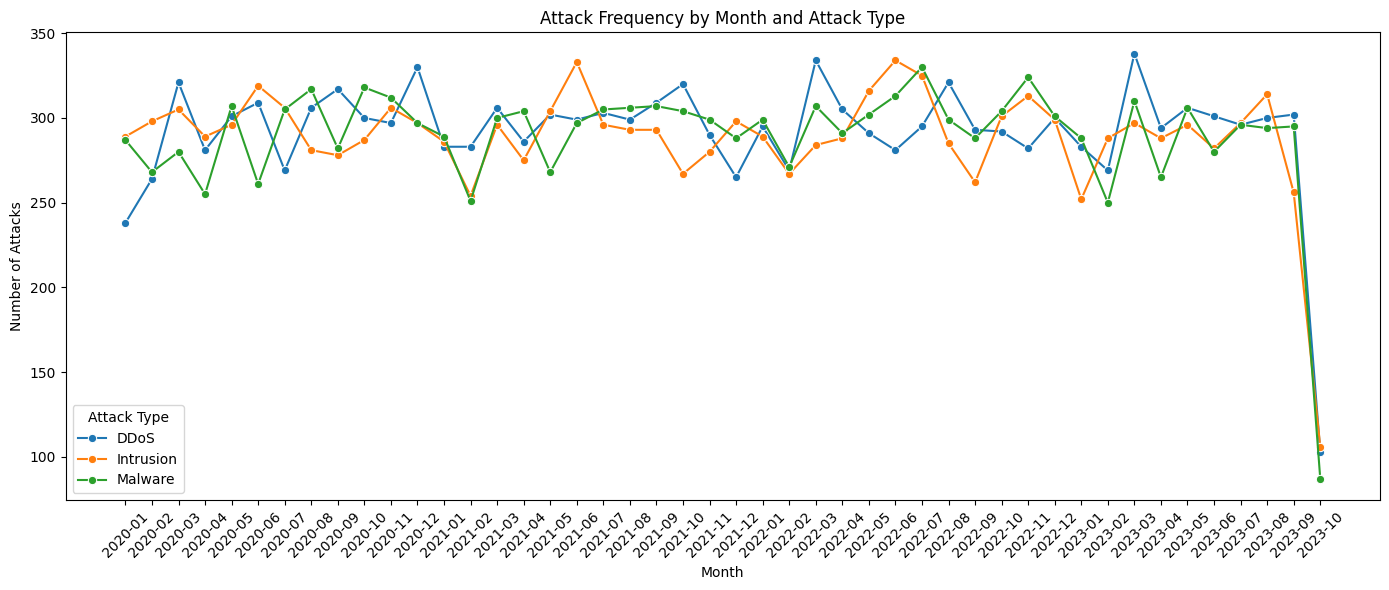

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_attacks, x='Month', y='Count', hue='Attack Type', marker='o')
plt.xticks(rotation=45)
plt.title("Attack Frequency by Month and Attack Type")
plt.xlabel("Month")
plt.ylabel("Number of Attacks")
plt.tight_layout()
plt.show()


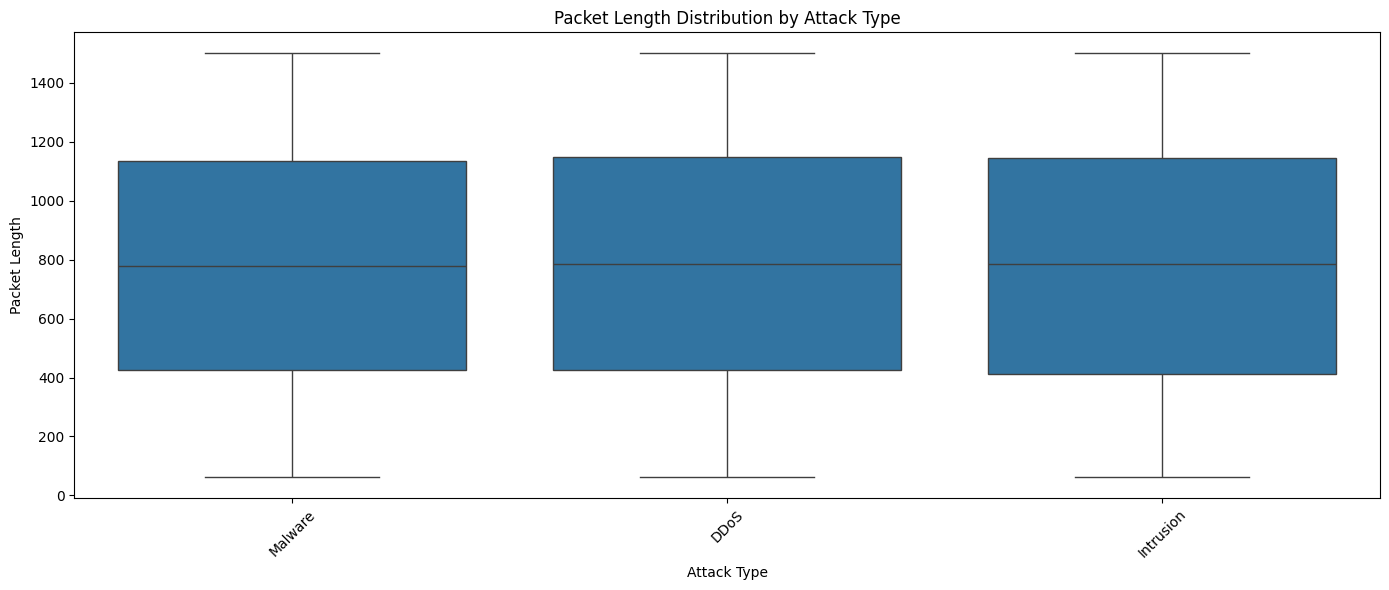

In [11]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x='Attack Type', y='Packet Length')
plt.xticks(rotation=45)
plt.title("Packet Length Distribution by Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("Packet Length")
plt.tight_layout()
plt.show()
